## Example: Estimate the avg. # of drinks it takes to get drunk

We would like to estimate the average (self reported from students in a Duke Statistics class) number of drinks it takes a person get drunk, we will assume that this is population data:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(7)
n = 100
mu, sigma = 5.39, 2.37
low, high = 0.0, 10.0

In [3]:
# draw from a truncated normal on [low, high]
def sample_truncnorm_numpy(n, mu, sigma, low, high):
    out = []
    batch = max(4*n, 1000)
    while len(out) < n:
        x = np.random.normal(mu, sigma, size = batch)
        x = x[(x>=low) & (x<= high)]
        out.extend(x.tolist())
    return np.array(out[:n])

In [4]:
try:
    from scipy.stats import truncnorm
    a, b = (low - mu)/sigma, (high-mu)/sigma
    data = truncnorm(a,b, loc=mu, scale=sigma).rvs(n, random_state=np.random.default_rng())
except Exception:
    data = sample_truncnorm_numpy(n, mu, sigma, low, high)

In [5]:
# compute sample stats
s_mu = np.mean(data)
s_sigma = np.std(data, ddof=0)

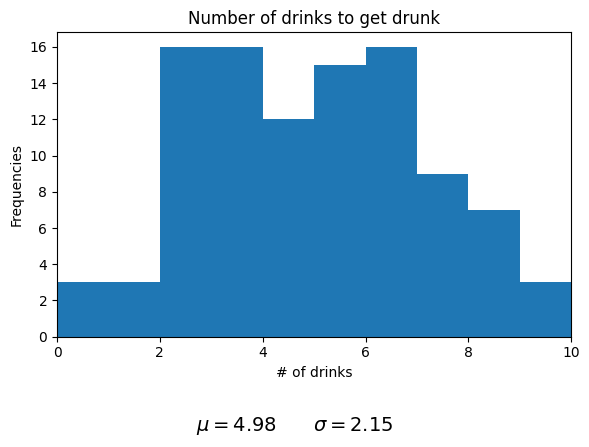

In [6]:
# plot
fig, ax = plt.subplots(figsize = (6,4))
ax.hist(data, bins = np.arange(low, high+1))
ax.set_title("Number of drinks to get drunk")
ax.set_xlim(low, high)
ax.set_xlabel("# of drinks")
ax.set_ylabel("Frequencies")

# annotate mu and sigma
txt = rf"$\mu = {s_mu:.2f}$" + "      " + rf"$\sigma = {s_sigma:.2f}$"
fig.text(0.5, -0.05, txt, ha="center", va="top", fontsize=14)

plt.tight_layout()
plt.show()

#### Effect of Increasing Number of Samples

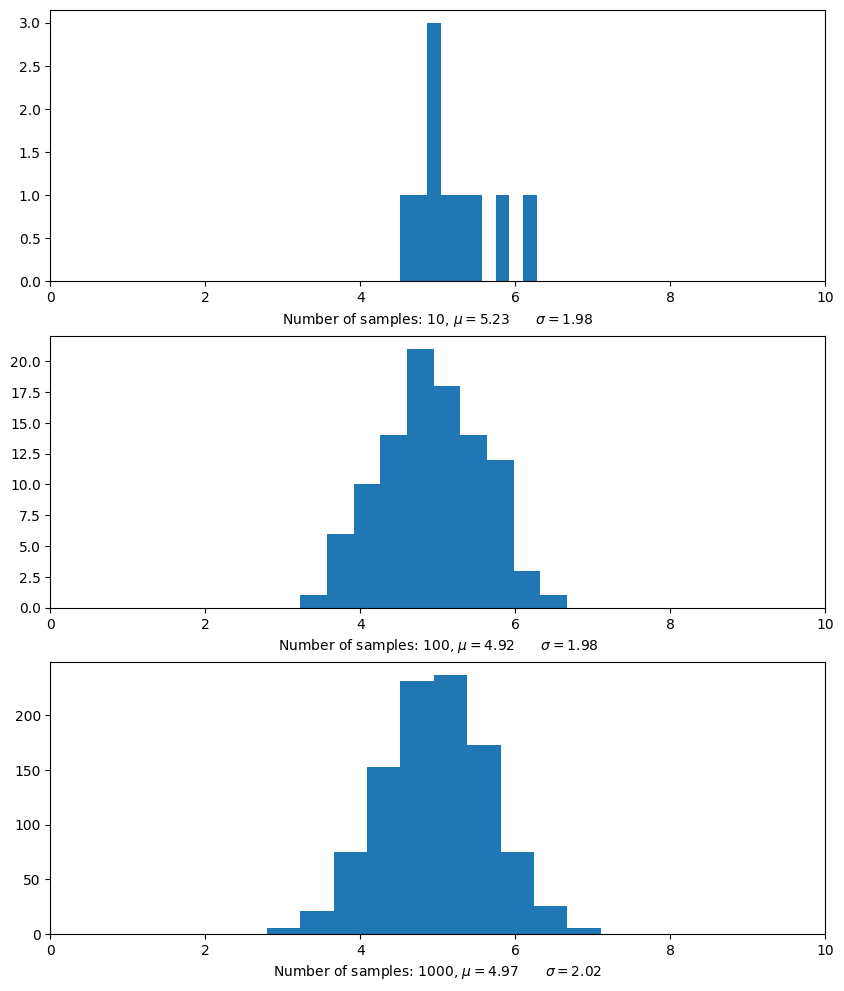

In [7]:
num_sample = [10, 100, 1000]
fig, axes = plt.subplots(3, figsize=(10,12))
for ax, num in enumerate(num_sample):
    mu = []
    sigma = []
    for _ in range(num):
        sample = np.random.choice(data, size = 10)
        mu.append(np.mean(sample))
        sigma.append(np.std(sample, ddof=0))
    
    axes[ax].hist(mu)
    axes[ax].set_xlim(0,10)
    axes[ax].set_xlabel(rf"Number of samples: {num}, $\mu = {np.mean(mu):.2f}$" + "      " + rf"$\sigma = {np.mean(sigma):.2f}$")